In [1]:
# import libraries
import numpy as np
import sys
import psi4
from helper_PFCI import PFHamiltonianGenerator
np.set_printoptions(threshold=sys.maxsize)
psi4.core.set_output_file('output.dat', False)

from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib import rcParams
import sys
np.set_printoptions(threshold=sys.maxsize)
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 12



We are going to read the energy eigenvalues and dipole matrix elements from .npy files.  We will also still create an instance of the PFHamiltonianGenerator class so we can use its build_pcqed_pf_hamiltonian() method, but it is not really important what details we use to instantiate this class... so we will use LiH in a minimal basis since this is a fast way to instantiate the class!

In [2]:
# read data from .npy files for formaldehyde casci(8,8) calculations

# !!! Change this to the correct path on your computer!
npy_folder = "/Users/jfoley19/Code/data_repository/NPY_Files/OHminus/"

# these file names should still be good
E_origin_npy_file = npy_folder + "OH_minus_r_0.9_displaced_0Ang_631g_fci_50_states_Energies.npy"
Mu_origin_npy_file = npy_folder + "OH_minus_r_0.9_displaced_0Ang_631g_fci_50_states_Dipoles.npy"

E_disp_npy_file = npy_folder + "OH_minus_r_0.9_displaced_20Ang_631g_fci_50_states_Energies.npy"
Mu_disp_npy_file = npy_folder + "OH_minus_r_0.9_displaced_20Ang_631g_fci_50_states_Dipoles.npy"


# store energy eigenvalues in E_array
E_origin_array = np.load(E_origin_npy_file)
# store dipole matrix elements in Mu_array
Mu_origin_array = np.load(Mu_origin_npy_file)

# store energy eigenvalues in E_array
E_disp_array = np.load(E_disp_npy_file)
# store dipole matrix elements in Mu_array
Mu_disp_array = np.load(Mu_disp_npy_file)

print(np.shape(E_origin_array))
print(np.shape(Mu_origin_array))

# print their shape so we know how many elements we have
print(np.shape(E_disp_array))
print(np.shape(Mu_disp_array))


# setup basic arguments to create an instance of the PFHamiltonianGenerator class
mol_str = """
    Li
    H 1 1.4
    symmetry c1
"""


options_dict = {
    "basis": "sto-3g",
    "scf_type": "pk",
    "e_convergence": 1e-10,
    "d_convergence": 1e-10,
}


cavity_free_dict = {
    'omega_value' : 0.12086,
    'lambda_vector' : np.array([0, 0, 0.05]),
    'ci_level' : 'fci',   
    'full_diagonalization' : True,
    'number_of_photons' : 0, 
}

# create the instance of our PFHamiltonianGenerator class
origin = PFHamiltonianGenerator(mol_str, options_dict, cavity_free_dict)
displaced = PFHamiltonianGenerator(mol_str, options_dict, cavity_free_dict)

(50,)
(50, 50, 3)
(50,)
(50, 50, 3)

Start SCF iterations:

Canonical RHF One-electron energy = -12.6946346236296055
CQED-RHF One-electron energy      = -12.6809948417116001
Nuclear repulsion energy          = 1.1339511657214287
Dipole energy                     = 0.0129085217276915
SCF Iteration   1: Energy = -7.8566740258646455   dE = -7.85667E+00   dRMS = 3.20530E-04
SCF Iteration   2: Energy = -7.8566790098824129   dE = -4.98402E-06   dRMS = 3.95666E-05
SCF Iteration   3: Energy = -7.8566791754252332   dE = -1.65543E-07   dRMS = 1.25930E-05
SCF Iteration   4: Energy = -7.8566792018488094   dE = -2.64236E-08   dRMS = 1.50801E-07
SCF Iteration   5: Energy = -7.8566792018491434   dE = -3.33955E-13   dRMS = 1.03800E-09
SCF Iteration   6: Energy = -7.8566792018491416   dE =  1.77636E-15   dRMS = 1.24962E-10
SCF Iteration   7: Energy = -7.8566792018491451   dE = -3.55271E-15   dRMS = 4.58454E-15
Total time for SCF iterations: 0.001 seconds 

QED-RHF   energy: -7.85667920 hartree
Psi4  SC

In [3]:
N_el = 50
N_ph = 50

omega = 0.21927747
lambda_vector = np.array([0., 0., 0.05])

# this instance is at the origin
origin.fast_build_pcqed_pf_hamiltonian(N_el, N_ph, omega, lambda_vector , E_origin_array, Mu_origin_array)

# this instance is displaced by 20 angstroms
displaced.fast_build_pcqed_pf_hamiltonian(N_el, N_ph, omega, lambda_vector , E_disp_array, Mu_disp_array)

In [4]:
# <d>_0 at origin
d_origin_uncoupled_gs = np.dot(lambda_vector, Mu_origin_array[0,0,:])

# <d>_0 displaced
d_disp_uncoupled_gs = np.dot(lambda_vector, Mu_disp_array[0,0,:])

# <d> at origin
d_origin_coupled_gs = np.dot( origin.PCQED_pf_vecs[:,0].conj().T, np.dot( origin.PCQED_MU, origin.PCQED_pf_vecs[:,0]))

# <d> displaced
d_disp_coupled_gs = np.dot( displaced.PCQED_pf_vecs[:,0].conj().T, np.dot( displaced.PCQED_MU, displaced.PCQED_pf_vecs[:,0]))

# print <d>_0 at origin
print(F' <d>_0 at origin {d_origin_uncoupled_gs}')

# print <d>_0 displaced
print(F' <d>_0 displaced {d_disp_uncoupled_gs}')

# print <d> at origin
print(F' <d> at origin {d_origin_coupled_gs}')

# print <d> displaced
print(F' <d> displaced {d_disp_coupled_gs}')


# print \delta_{<d>}
dd_origin = d_origin_coupled_gs - d_origin_uncoupled_gs
print(F' delta_<d> at origin {dd_origin}')

dd_disp = d_disp_coupled_gs - d_disp_uncoupled_gs
print(F' delta_<d> at origin {dd_disp}')


 <d>_0 at origin 0.030234883527336033
 <d>_0 displaced -1.8594912419295442
 <d> at origin 0.030573865023486795
 <d> displaced -1.8591522604333754
 delta_<d> at origin 0.00033898149615076145
 delta_<d> at origin 0.0003389814961687332


# Perturbation Theory for the Cavity:

$$ \hat{H} = \hat{H}_0 + \lambda \hat{H}' \tag{1} $$

where 

$$\hat{H}_0 = \frac{1}{2} \hat{p}^2 + \frac{1}{2}\omega^2 \hat{q}^2 \tag{2} $$

and 

$$ \hat{H}' = -\omega \hat{d} \hat{q} \tag{3} $$ 

where $\hat{d} = \lambda \cdot \hat{\mu}$, $\hat{p} = i \sqrt{\frac{\hbar \omega}{2}} (\hat{b}^{\dagger} - \hat{b} )$, and $\hat{q} =  \sqrt{\frac{\hbar}{2\omega}} (\hat{b}^{\dagger} + \hat{b} )$.  

Note that this perturbation is the bilinear coupling term, which is often written as 

$$ \hat{H}_{blc} = - \omega \hat{\mu} {\bf A}_0 (\hat{b}^{\dagger} + \hat{b}) \tag{4} $$

with ${\bf A}_0 = \sqrt{\frac{\hbar}{2\omega \epsilon_0 L^3}} \hat{e}$.  Here we have used the fact that $\lambda = \sqrt{\frac{1}{\epsilon_0 L^3}} $ to rewrite this term in the form shown in Eq. 3.


In [5]:
import numpy as np
from matplotlib import pyplot as plt
import numpy as np
from numpy import trapz
from scipy.special import hermite
from math import factorial
def compute_alpha(omega, hbar):
    """ Helper function to compute \alpha = \omega / \hbar
    
    Arguments
    ---------
    omega : float
        The photon frequency
        
    hbar : float
        reduced planck's constant
        
    Returns
    -------
    alpha : float
        \alpha = omega / hbar
    
    """
    # compute alpha
    alpha =  omega / hbar
    
    # return alpha
    return alpha

def N(n, alpha):
    """ Helper function to take the quantum number n of the Harmonic Oscillator and return the normalization constant
        
    Arguments
    ---------
    n : int
        the quantum state of the harmonic oscillator
        
    Returns
    -------
    N_n : float
        the normalization constant
    """
    
    return  np.sqrt( 1 / (2 ** n * factorial(n)) ) * ( alpha / np.pi ) ** (1/4) 

def psi(n, alpha, r, r_eq):
    """ Helper function to evaluate the Harmonic Oscillator energy eigenfunction for state n
        
    Arguments
    ---------
    n : int
        the quantum state of the harmonic oscillator
        
    alpha : float
        alpha value
        
    
    r : float
        position at which psi_n will be evaluated
        
    r_eq : float
        equilibrium bondlength
        
    Returns
    -------
    psi_n : float
        value of the harmonic oscillator energy eigenfunction
        
    """
    
    Hr = hermite(n)
    
    psi_n = N(n, alpha) * Hr( np.sqrt(alpha) * ( r - r_eq )) * np.exp( -0.5 * alpha  * (r - r_eq)**2)
    
    return psi_n

def harmonic_eigenvalue(n, omega, hbar):
    """ Helper function to evaluate the energy eigenvalue of the harmonic oscillator for state n"""
    
    return hbar * omega * (n + 1/2)


def potential_matrix_element(n, m, alpha, r, r_eq, V_p):
    """ Helper function to compute <n|V_p|m> where V_p is the perturbing potential
    
    Arguments
    ---------
    n : int
        quantum number of the bra state
        
    m : int
        quantum number of the ket state
        
    alpha : float
        alpha constant for bra/ket states
        
    r : float
        position grid for bra/ket states
        
    r_eq : float
        equilibrium bondlength for bra/ket states
        
    V_p : float
        potential array
        
    Returns
    -------
    V_nm : float
        <n | V_p | m > 
    
    """
    # bra 
    psi_n = psi(n, alpha, r, r_eq)
    
    # ket 
    psi_m = psi(m, alpha, r, r_eq)
    
    # integrand
    integrand = np.conj(psi_n) * V_p * psi_m
    
    # integrate
    V_nm = np.trapz(integrand, r)
    
    return V_nm

In [6]:

# equilibrium bondlength in Angstroms
r_eq_ang = 0

# atomic mass units to kg
amu_to_kg = 1.66054e-27

# angstroms to meters
ang_to_m = 1e-10

# electron volts to Jouls
eV_to_J = 1.60218e-19

# electron volts to atomic units of energy (Hartrees)
eV_to_au = 1 / 27.211 #0.0367493

# angstroms to atomic units of length (Bohr radii)
au_to_ang = 0.52917721067121

# atomic mass units to atomic units of mass 
amu_to_au = 1822.89


# array of bondlength values
r = np.linspace(-6, 6 , 200)

# equilibrium bondlength in SI
r_eq_au = r_eq_ang / au_to_ang


hbar_au = 1

alpha = compute_alpha(omega, hbar_au)
# compute psi_0 along the r grid


# h in SI
h_SI = np.pi * 2

def evaluate_Harmonic(r, omega, r_eq):
    """ Helper function to evaluate the Harmonic potential at a given value of r
    
    Arguments
    ---------
    r : float
        value(s) of r to evaluate potential at
        
    omega : float
        value of the frequency
        
    r_eq : float
        equilibrium position of oscillator
        
    Returns
    -------
    V_m : float
        value of the potential at r
    
    """
    return 1 / 2 * omega ** 2 * r ** 2




# array of Morse potential values



In [7]:
# print <d>_0 at origin
print(F' <d>_0 at origin {d_origin_uncoupled_gs}')

# print <d>_0 displaced
print(F' <d>_0 displaced {d_disp_uncoupled_gs}')

# print <d> at origin
print(F' <d> at origin {d_origin_coupled_gs}')

# print <d> displaced
print(F' <d> displaced {d_disp_coupled_gs}')


# print \delta_{<d>}
dd_origin = d_origin_coupled_gs - d_origin_uncoupled_gs
print(F' delta_<d> at origin {dd_origin}')

dd_disp = d_disp_coupled_gs - d_disp_uncoupled_gs
print(F' delta_<d> at origin {dd_disp}')

 <d>_0 at origin 0.030234883527336033
 <d>_0 displaced -1.8594912419295442
 <d> at origin 0.030573865023486795
 <d> displaced -1.8591522604333754
 delta_<d> at origin 0.00033898149615076145
 delta_<d> at origin 0.0003389814961687332


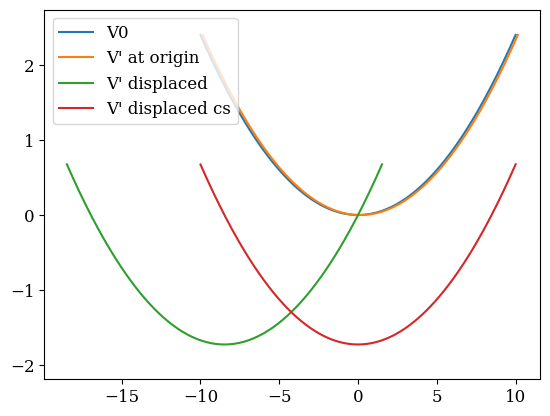

In [8]:

# set up grid for uncoupled potential
MIN_R = -10
MAX_R = 10

# set up grid for unperturbed potential
r = np.linspace(MIN_R, MAX_R , 200)

# set up grid for coupled potential for system at origin
r_origin_pert = np.linspace(MIN_R + d_origin_coupled_gs/ omega, MAX_R + d_origin_coupled_gs/ omega , 200)

# set up grid for coupled potential for system displaced from origin
r_disp_pert = np.linspace(MIN_R + d_disp_coupled_gs/ omega, MAX_R + d_disp_coupled_gs/ omega , 200)

# set up grid for coupled potential for system displaced from origin after coherent state transformation
r_disp_pert_cs = np.linspace(MIN_R + dd_disp / omega, MAX_R + dd_disp / omega , 200)

# set up unperturbed potential 
V_H = evaluate_Harmonic(r, omega, r_eq_au)

# set up perturbed potential 
V_H_p = 1 / 2 * ( omega * r_origin_pert - d_origin_coupled_gs) ** 2  - 1 / 2 * d_origin_coupled_gs ** 2

# set up perturbed potential 
V_H_disp_p = 1 / 2 * ( omega * r_disp_pert - d_disp_coupled_gs) ** 2  - 1 / 2 * d_disp_coupled_gs ** 2

# set up coherent state transformed perturbed potential
V_H_p_cs = 1 / 2 * (omega * r_disp_pert_cs + d_disp_coupled_gs - d_disp_uncoupled_gs) ** 2 - 1 / 2 * d_disp_coupled_gs ** 2


# compute ground state and first excited state lines
E0_val = omega / 2
E1_val = 3 * omega / 2
E2_val = 5 * omega / 2

E_0 = np.ones_like(V_H) * E0_val
E_1 = np.ones_like(V_H) * E1_val
E_2 = np.ones_like(V_H) * E2_val


plt.plot(r, V_H, label="V0")
plt.plot(r_origin_pert, V_H_p, label="V' at origin")
plt.plot(r_disp_pert, V_H_disp_p, label="V' displaced")
plt.plot(r_disp_pert_cs, V_H_p_cs , label="V' displaced cs")
plt.ylim(-4 * E2_val, 5 * E2_val)
plt.legend()
plt.show()


 First order coefficient is -0.6155976684528432
 Second order coefficient is 0.5359310448468947
 First order cs coefficient is 0.00011224267271228518
 Second order cs coefficient is 1.7816852375263984e-08


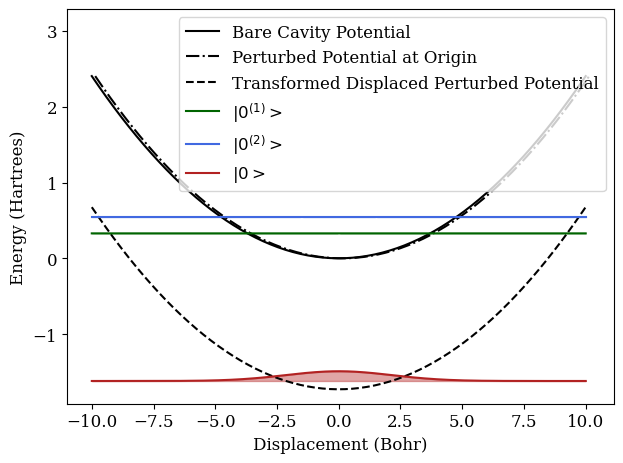

In [10]:
fig, ax = plt.subplots()

COLOUR1 = 'darkorchid'
COLOUR2 = 'mediumspringgreen'
COLOUR3 = 'royalblue' 
COLOUR4 = 'darkorchid' 

PCOLOUR1 = "firebrick"
PCOLOUR2 = "darkgreen"
PCOLOUR3 = "royalblue"

## set up grid for unperturbed potential
#r = np.linspace(MIN_R, MAX_R , 200)
## set up grid for coupled potential for system at origin
#r_origin_pert = np.linspace(MIN_R + d_origin_coupled_gs/ omega, MAX_R + d_origin_coupled_gs/ omega , 200)
## set up grid for coupled potential for system displaced from origin
#r_disp_pert = np.linspace(MIN_R + d_disp_coupled_gs/ omega, MAX_R + d_disp_coupled_gs/ omega , 200)
## set up grid for coupled potential for system displaced from origin after coherent state transformation
#r_disp_pert_cs = np.linspace(MIN_R + dd_disp / omega, MAX_R + dd_disp / omega , 200)
# print <d>_0 at origin
#print(F' <d>_0 at origin {d_origin_uncoupled_gs}')
# print <d>_0 displaced
#print(F' <d>_0 displaced {d_disp_uncoupled_gs}')
# print <d> at origin
#print(F' <d> at origin {d_origin_coupled_gs}')
# print <d> displaced
#print(F' <d> displaced {d_disp_coupled_gs}')



# unclear what this factor does
QPAD_FRAC = 1.3
# Scale the wavefunctions by this much so they don't overlap
SCALING = 0.7

# unperturbed ground state
psi_0 = psi(0, alpha, r, r_eq_au)
# unperturbed first excited state
psi_1 = psi(1, alpha, r, r_eq_au)
# unperturbed second excited state
psi_2 = psi(2, alpha, r, r_eq_au)

# compute  -<1 | w <d>_disp q | 0>/(E_0 - E_1) |1> for displaced system
coeff_fo = np.trapz(psi_1 * omega * d_disp_coupled_gs * r * psi_0, r)
psi_0_fo = -coeff_fo / (E0_val - E1_val) * psi_1

# compute -<1 | w (<d> - <d>0)_disp q | 0>/(E_0 - E_1) |1>
coeff_fo_cs = np.trapz(psi_1 * omega * dd_disp * r * psi_0, r)
psi_0_fo_cs = -coeff_fo_cs / (E0_val - E1_val) * psi_1

# compute  <2 | w <d>_disp q | 1> <1 | w <d>_disp q | 0>/[(E_0 - E_1)(E_0 - E_2)] |2>
coeff_so = np.trapz(psi_2 * omega * d_disp_coupled_gs * r * psi_1, r) * coeff_fo
psi_0_so = coeff_so / ((E0_val - E1_val) * (E0_val - E2_val)) * psi_2

# compute  <2 | w (<d>-<d>0)_disp q | 1> <1 | w (<d>-<d>0)_disp q | 0>/[(E_0 - E_1)(E_0 - E_2)] |2>
coeff_so_cs = np.trapz(psi_2 * omega * dd_disp * r * psi_1, r) * coeff_fo_cs
psi_0_so_cs = coeff_so_cs / ((E0_val - E1_val) * (E0_val - E2_val)) * psi_2

print(f' First order coefficient is {coeff_fo}')
print(f' Second order coefficient is {coeff_so}')

print(f' First order cs coefficient is {coeff_fo_cs}')
print(f' Second order cs coefficient is {coeff_so_cs}')


def plot_func(ax, f, COLOUR, lab, scaling=1, yoffset=0 ):
    """Plot f*scaling with offset yoffset.

    The curve above the offset is filled with COLOUR1; the curve below is
    filled with COLOUR2.

    """
    ax.plot(r, f*scaling + yoffset, color=COLOUR, label=lab)
    ax.fill_between(r, f*scaling + yoffset, yoffset, f > 0.,
                    color=COLOUR, alpha=0.2)
    ax.fill_between(r, f*scaling + yoffset, yoffset, f < 0.,
                    color=COLOUR, alpha=0.2)


def plot_func_offset(ax, r_grid, f, COLOUR, lab, scaling=1, yoffset=0):
    """Plot f*scaling with offset yoffset.

    The curve above the offset is filled with COLOUR1; the curve below is
    filled with COLOUR2.

    """
    ax.plot(r_grid, f*scaling + yoffset, color=COLOUR, label=lab)
    ax.fill_between(r_grid, f*scaling + yoffset, yoffset, f > 0.,
                    color=COLOUR, alpha=0.4)
    ax.fill_between(r_grid, f*scaling + yoffset, yoffset, f < 0.,
                    color=COLOUR, alpha=0.4)

def plot_prod_offset(ax, f, scaling=1, yoffset=0):
    """Plot f*scaling with offset yoffset.

    The curve above the offset is filled with COLOUR1; the curve below is
    filled with COLOUR2.

    """
    ax.plot(r_disp, f*scaling + yoffset, color=COLOUR1)
    ax.fill_between(r_disp, f*scaling + yoffset, yoffset, f > 0.,
                    color=COLOUR4, alpha=0.5)
    ax.fill_between(r_disp, f*scaling + yoffset, yoffset, f < 0.,
                    color=COLOUR4, alpha=0.5)
    
    
#psi_0**2+E_0
plt.plot(r, V_H, color='k', linewidth=1.5, label="Bare Cavity Potential")
plt.plot(r_origin_pert, V_H_p, color='k', linewidth=1.5, linestyle="dashdot", label="Perturbed Potential at Origin")
#plt.plot(r_disp_pert, V_H_disp_p, color='k', linewidth=1.5, linestyle="dashed", label="Perturbed Potential")
#plot_func_offset(ax, r_disp_pert, psi_0_fo, PCOLOUR2, "$|0^{(1)}>$", scaling=0.25, yoffset =  (E1_val -  1 / 2 * d_disp_coupled_gs ** 2))
#plot_func_offset(ax, r_disp_pert, psi_0_so, COLOUR3, "$|0^{(2)}>$", scaling=0.25, yoffset =  (E2_val -  1 / 2 * d_disp_coupled_gs ** 2))
plt.plot(r_disp_pert_cs, V_H_p_cs, color='k', linewidth=1.5, linestyle="dashed", label="Transformed Displaced Perturbed Potential")
#plot_func_offset(ax, r_disp_pert, psi_0_fo_cs, PCOLOUR2, "$|0^{(1)}>$", scaling=0.25, yoffset =  (E1_val -  1 / 2 * d_disp_coupled_gs ** 2))
#plot_func(ax, psi_0, PCOLOUR1, "$|0>$", scaling=0.25, yoffset =  E0_val)
plot_func(ax, psi_0_fo_cs, PCOLOUR2, "$|0^{(1)}>$", scaling=0.25, yoffset =  E1_val)
plot_func(ax, psi_0_so_cs, COLOUR3, "$|0^{(2)}>$", scaling=0.25, yoffset =  E2_val)
plot_func_offset(ax, r_disp_pert_cs, psi_0, PCOLOUR1, "$|0>$", scaling=0.25, yoffset =  (E0_val -  1 / 2 * d_disp_coupled_gs ** 2))
plt.ylabel("Energy (Hartrees)")
plt.xlabel("Displacement (Bohr)")
plt.legend()
plt.ylim(-3.5 * E2_val, 6 * E2_val)
plt.tight_layout()
plt.savefig("OHminus_PT_on_CS_Cav.png", dpi=200)
plt.show()


In [11]:
# first order coefficient is  <d> <1|q|0> = <d> / (sqrt(2 w) )
_expected_fo_coeff = d_disp_coupled_gs / (np.sqrt(2 * omega))
_expected_fo_cs_coeff = dd_disp / (np.sqrt(2 * omega))

# second order coefficient is <d>^2 / (2 sqrt(2) w) 
_expected_so_coeff = d_disp_coupled_gs ** 2 / (2 * np.sqrt(2) * omega) 
_expected_so_cs_coeff = dd_disp ** 2 / (2 * np.sqrt(2) * omega) 


print(F' analytic  first order coefficient: {_expected_fo_coeff}')
print(F' analytic second order coefficient: {_expected_so_coeff}')

print(F' analytic  first order cs coefficient: {_expected_fo_cs_coeff}')
print(F' analytic second order cs coefficient: {_expected_so_cs_coeff}')


 analytic  first order coefficient: -2.807391336031745
 analytic second order coefficient: 5.573023992501379
 analytic  first order cs coefficient: 0.0005118750818167768
 analytic second order cs coefficient: 1.8527336065513377e-07


In [ ]:
x = np.linspace(-100, 100, 500)
k = 0.3
sig = 0.002
ci = 0. + 1j

p = np.exp(-sig * x ** 2 ) * np.exp( ci * k * x)

plt.plot(x, p)
plt.show()